# Новое заведение общественного питания в Москве

- Автор: Кушкина Алика
- Дата: 04.11.2025

### Цели и задачи проекта

<font color='#777778'> Основываясь на датасете с заведениями общественного питания Москвы, составленного на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года, мы должны помочь инвесторам из фонда *** в выборе подходящего места для открытия нового заведения общественного питания.</font>
    
    Цель проекта - провести исследовательский анализ рынка общественного питания Москвы.

Задачи:

- Познакомиться с данными и изучить общую информацию о предоставленных датасетах;
- Объединить данные двух датасетов в один, с которым будем работать далее;
- Подготовить данные к исследовательскому анализу, осуществив их предобработку;
- Провести исследовательский анализ данных, ответив на все поставленные вопросы. При исследовании данных использовать визуализации;
- Сформулировать выводы и рекомендации по проделанной работе.

### Содержимое проекта

1. Загрузка данных и знакомство с ними;

2. Предобработка данных;

3. Исследовательский анализ данных;

4. Итоговый вывод и рекомендации.

---

## 1. Загрузка данных и знакомство с ними

- Загрузим данные о заведениях общественного питания Москвы. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn. Данные датасетов сохраним в двух переменных: `rest_info_df` и `rest_price_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Выгружаем данные в переменные bank_df и clients_df
rest_info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомимся с данными датасета rest_info.csv — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [3]:
# Выводим первые строки датафрейма на экран
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Используем метод shape для определения размеров датафрейма
rest_info_df.shape

(8406, 9)

- Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания. 

После первичного анализа данных можно сделать следующие выводы: 
- Представленные данные содержат текстовые значения, которые хранятся в типе данных object, а также числовые значения, которые хранятся в типах данных int64 или float64. 
- Значения в столбцах chain представлены целыми числами, которое показывает является ли заведение сетевым и содержит значения 1 или 0 — размерность этих данных можно оптимизировать. 
- Пропуски содержатся только в столбцах seats и hours (3 611 и 536 соответственно). Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных. 

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. Теперь познакомимся с данными датасета rest_price.csv.

In [6]:
# Выводим первые строки датафрейма на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# Используем метод shape для определения размеров датафрейма
rest_price_df.shape

(4058, 5)

Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов приведено к единому виду.
- Типы данных соответствуют содержимому. 
- Пропуски содержатся во всех столбцах, кроме id: в столбце price пропущено 743 значения, в столбце avg_bill - 242, в middle_avg_bill - 909, в middle_coffee_cup - 3523.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что в датасете `rest_price.csv` очень много пропущенных значений. Однако стоит отметить, что сами данные соответствуют описанию и выглядят корректными.

---

### Промежуточный вывод


- Датасет rest_info.csv содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания. 

После первичного анализа данных можно сделать следующие выводы: 
- Представленные данные содержат текстовые значения, которые хранятся в типе данных object, а также числовые значения, которые хранятся в типах данных int64 или float64. 
- Значения в столбцах chain представлены целыми числами, которое показывает является ли заведение сетевым и содержит значения 1 или 0 — размерность этих данных можно оптимизировать. 
- Пропуски содержатся только в столбцах seats и hours (3 611 и 536 соответственно). Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных. 

Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов приведено к единому виду.
- Типы данных соответствуют содержимому. 
- Пропуски содержатся во всех столбцах, кроме id: в столбце price пропущено 743 значения, в столбце avg_bill - 242, в middle_avg_bill - 909, в middle_coffee_cup - 3523.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что в датасете `rest_price.csv` очень много пропущенных значений. Однако стоит отметить, что сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один, с которым продолжим работу.

Каждая строка в этих датафреймах — это информация о заведении, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору заведения. При соединении оставим только полные данные — это значит, что значение `id` должно быть в двух датафреймах.

In [9]:
# Соединяем данные в единый датафрейм df
df = rest_info_df.merge(rest_price_df, on='id', how='left')

In [10]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [11]:
# Используем метод shape для определения размеров созданного датафрейма
df.shape

(8406, 13)

В новом датафрейме 8406 строк и 13 столбцов.

## 2. Предобработка данных


<font color='#777778'>На предыдущем этапе мы выяснили, что все типы данных соответствуют содержимому. Поэтому осуществлять преобразования не требуется. </font>

При первичном анализе мы обнаружили пропуски в столбцах hours, seats, price, avg_bill, middle_avg_bill, middle_coffee_cup. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

In [12]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [13]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме df обнаружено: 
- 536 пропусков в столбце hours — это 6% данных;
- 3 611 пропуск в столбце seats — это 43% данных. Количество пропусков достаточно большое, чтобы их просто удалить;
Пропуски в этом столбце могут быть вызваны: отсутсвием посадочных мест в заведении или техническим сбоем при обработке данных.
- 5 091 пропуск в столбце price — это 60% данных.Количество пропусков достаточно большое, чтобы их просто удалить;
Пропуски в этом столбце могут быть вызваны: отсутсвием четкой градации (с указанием конкретной стоимости), что затрудняло ответ респондентов на данный вопрос или техническим сбоем при обработке данных.
- 4 590 пропусков в столбце avg_bill — это 55% данных;
Пропуски в этом столбце могут быть вызваны: трудностью выбора респондентами конкретного товара или техническим сбоем при обработке данных.
- 5 257 пропусков в столбце middle_avg_bill — это 63% данных.Количество пропусков достаточно большое, чтобы их просто удалить;
Пропуски в этом столбце могут быть вызваны: условиями, которые должны были выполняться для столбца avg_bill или техническим сбоем при обработке данных.
- 7 871 пропуск в столбце middle_coffee_cup — это 94% данных. Количество пропусков достаточно большое, чтобы их просто удалить. 
Пропуски в этом столбце могут быть вызваны: условиями, которые должны были выполняться для столбца avg_bill, а также отстутствием в заведении такого товара как "капучино" или техническим сбоем при обработке данных.


In [14]:
# Проверяем уникальные значения в столбцах
for column in ['hours', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце hours:
['Нет информации'
 'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30'
 'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00' ...
 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно'
 'чт-вс 20:00–06:00' nan]

Уникальные значения в столбце seats:
[0.000e+00 1.000e+00 2.000e+00 3.000e+00 4.000e+00 5.000e+00 6.000e+00
 7.000e+00 8.000e+00 9.000e+00 1.000e+01 1.200e+01 1.300e+01 1.400e+01
 1.500e+01 1.600e+01 1.700e+01 1.800e+01 1.900e+01 2.000e+01 2.100e+01
 2.200e+01 2.400e+01 2.500e+01 2.600e+01 2.700e+01 2.800e+01 2.900e+01
 3.000e+01 3.200e+01 3.300e+01 3.400e+01 3.500e+01 3.600e+01 3.700e+01
 3.800e+01 3.900e+01 4.000e+01 4.100e+01 4.200e+01 4.300e+01 4.400e+01
 4.500e+01 4.600e+01 4.700e+01 4.800e+01 4.900e+01 5.000e+01 5.100e+01
 5.200e+01 5.300e+01 5.400e+01 5.500e+01 5.600e+01 5.800e+01 6.000e+01
 6.100e+01 6.200e+01 6.300e+01 6.400e+01 6.500e+01 6.600e+01 6.700e+01
 6.800e+01 6.900e+01 7.000e+01 7.200e+01 

Все значения выглядят корректными.

Было принято решение оставить все столбцы без изменений.

 

- Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. 

In [15]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по id заведений должны быть уникальными:

In [16]:
# Проверяем неявные дубликаты в датафрейме df
df.duplicated(subset='id').sum()

np.int64(0)

Тут тоже всё хорошо. Теперь проверим корректность написания категориальных значений в данных df

In [17]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['name', 'address', 'district', 'category']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']

Уникальные значения в столбце address:
['Москва, 1-й Автозаводский проезд, 5'
 'Москва, 1-й Балтийский переулок, 3/25'
 'Москва, 1-й Варшавский проезд, 1Ас9' ...
 'Москва, шоссе Энтузиастов, 86А, корп. 3' 'Москва, шоссе Энтузиастов, с2'
 'Москва, № 7']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']



- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [18]:
def is_24_7(hours):
    if hours == 'ежедневно, круглосуточно': 
        return True
    else:
        return False

df['is_24_7'] = df['hours'].apply(is_24_7)


In [19]:
# Подсчитаем количество значений True в столбце is_24_7 
count_true = df['is_24_7'].sum()
print(count_true)

730


---

### Промежуточный вывод


В результате предобработки данных были выполнены следующие действия:

- Изучены пропуски в данных:

536 пропусков в столбце hours — это 6% данных;

3 611 пропуск в столбце seats — это 43% данных. Учитывая это количество, пропуски могут отражать особенности заведений (отсутствие посадочных мест) и не являться ошибкой в данных. Поэтому их оставили как есть;

5 091 пропуск в столбце price — это 60% данных. Пропуски оставили без изменений, так как отсутствие данных могло быть связано с затруднением респондента при ответе на данный вопрос в связи с недостаточно четкой градацией вариантов ответа (без указания конкретных числовых значений);

4 590 пропусков в столбце avg_bill — это 55% данных. Пропуски оставили без изменений, так как отсутствие данных могло быть связано с затруднением респондента в выборе одного конкретного товара;

5 257 пропусков в столбце middle_avg_bill — это 63% данных.Пропуски в этом столбце также оставили без изменений;

7 871 пропуск в столбце middle_coffee_cup — это 94% данных. Учитывая это количество, пропуски могут отражать особенности заведений (отсутствие такого товара как "капучино")  и не являться ошибкой в данных. Поэтому их оставили как есть.

Было принято решение оставить все столбцы без изменений.

- Данные проверили на явные и неявные дубликаты — в данных их нет.
​


## 3. Исследовательский анализ данных


---

### Задача 1

Исследуем количество объектов общественного питания по каждой категории. 

In [20]:
# Подсчитам количество заведений по каждой категории
df['category'].value_counts()



category
кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

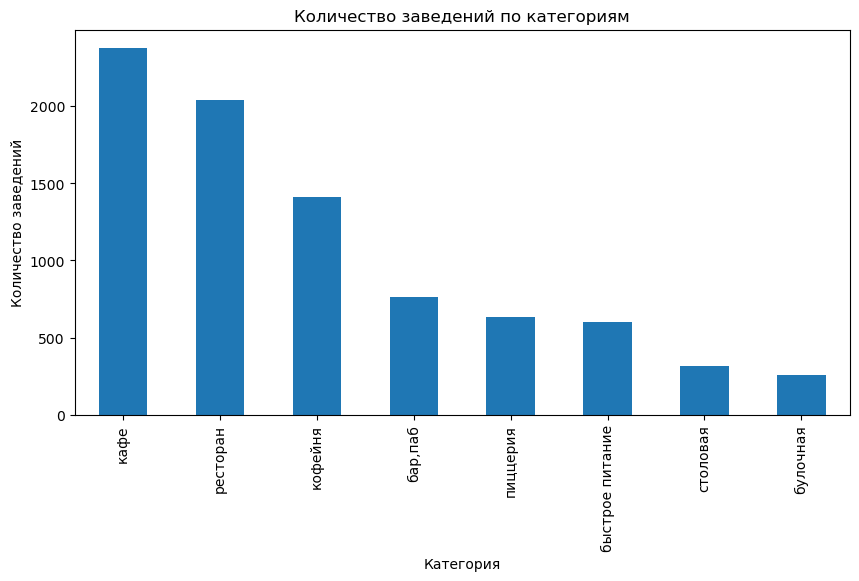

In [21]:
# Визуализируем результаты
df['category'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.show()
 

Мы видим, что больше всего заведений являются кафе (2 003) и ресторанами (1969), а наименьшее число заведений представлено столовыми (306) и булочными (249).
Следовательно, кафе и рестораны, с одной стороны, являются самыми выстребованными заведениями на рынке общественного питания Москвы, а с другой, для новой компании это может представлять трудности, ведь существует большая конкуренция. Также проще всего будет открыть столовую или булочную, однако это, вероятно, не будет приносить много прибыли, т.к. подобные заведения не очень востребованы. 

In [22]:
# Найдем распределение заведений по каждой категории в процентах
df['category'].value_counts(normalize=True)

category
кафе               0.282893
ресторан           0.243041
кофейня            0.168094
бар,паб            0.091006
пиццерия           0.075303
быстрое питание    0.071734
столовая           0.037473
булочная           0.030454
Name: proportion, dtype: float64

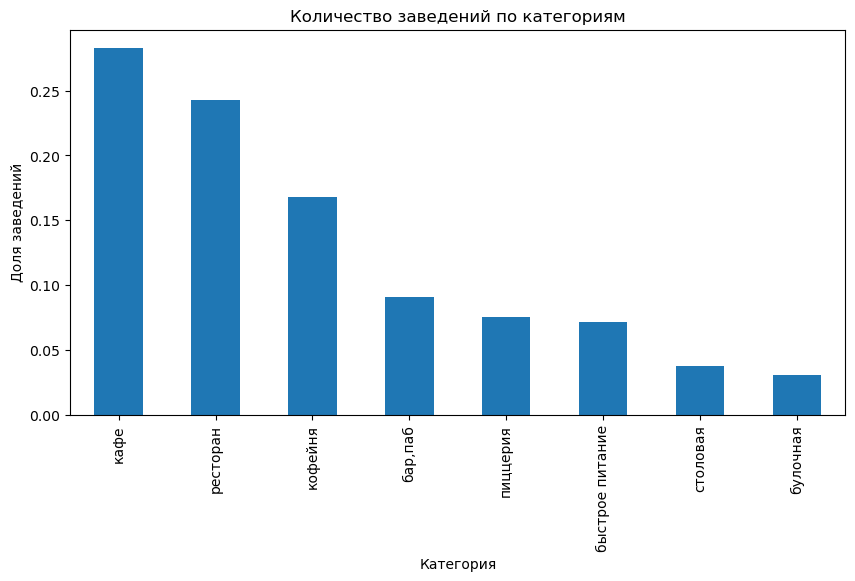

In [23]:
# Визуализируем результаты
df['category'].value_counts(normalize=True).plot(kind='bar', figsize=(10, 5))
plt.title('Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Доля заведений')
plt.show()

Скорректируем наш вывод с учетом процентного распределения по категориям:

Мы видим, что больше всего заведений являются кафе (2 003 или 25,4%) и ресторанами (1 969 или 25,0%), а наименьшее число заведений представлено столовыми (306 ил 3,9%) и булочными (249 или 3,2%).
Следовательно, кафе и рестораны, с одной стороны, являются самыми выстребованными заведениями на рынке общественного питания Москвы, а с другой, для новой компании это может представлять трудности, ведь существует большая конкуренция. Также проще всего будет открыть столовую или булочную, однако это, вероятно, не будет приносить много прибыли, т.к. подобные заведения не очень востребованы. 

---

### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. 

In [24]:
# Еще раз определим уникальные административные районы
df['district'].unique()


array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [25]:
# Подсчитам количество заведений в каждом районе
df['district'].value_counts()


district
Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

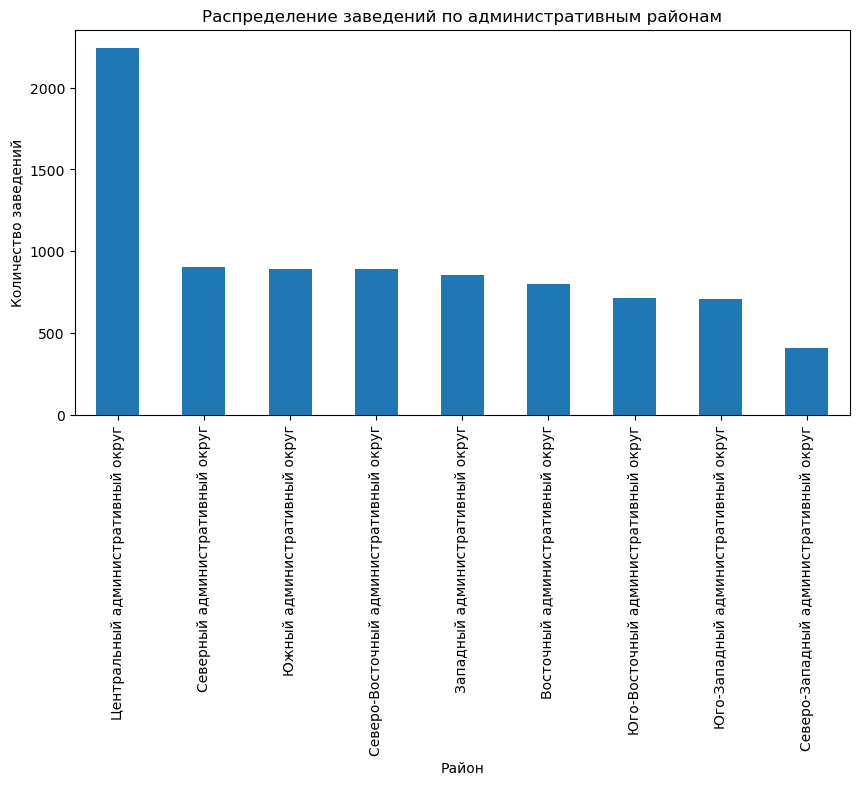

In [26]:
# Визуализируем данные
df['district'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Распределение заведений по административным районам')
plt.xlabel('Район')
plt.ylabel('Количество заведений')
plt.show()
 

In [27]:
# Отфильтруем данные
cao_df = df[df['district'] == 'Центральный административный округ']


In [28]:
# Посчитаем кол-во заведений по категориям в ЦАО
category_counts_cao = cao_df['category'].value_counts()
print(category_counts_cao)

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64


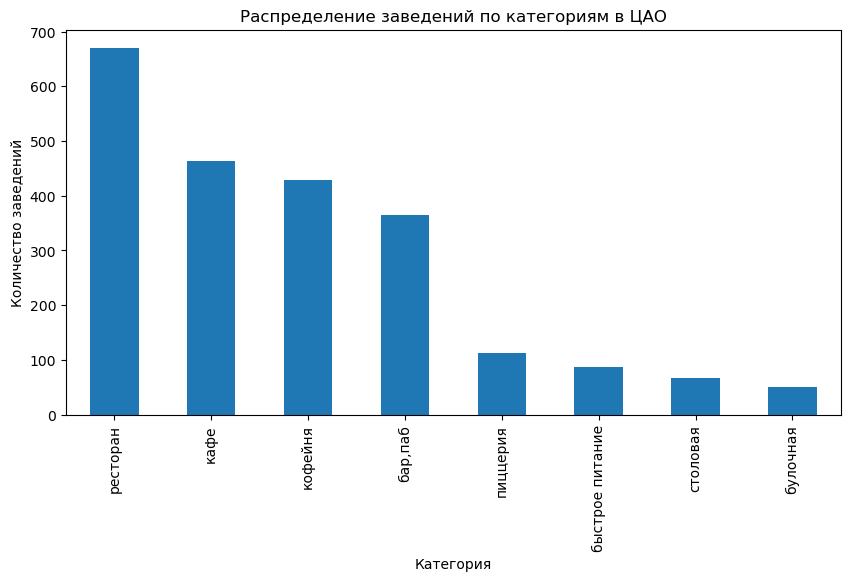

In [29]:
# Визуализируем данные
category_counts_cao.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение заведений по категориям в ЦАО')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.show()

In [30]:
# Посчитаем долю заведений по категориям в ЦАО
category_share_cao = cao_df['category'].value_counts(normalize=True)
print(category_share_cao)

category
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: proportion, dtype: float64


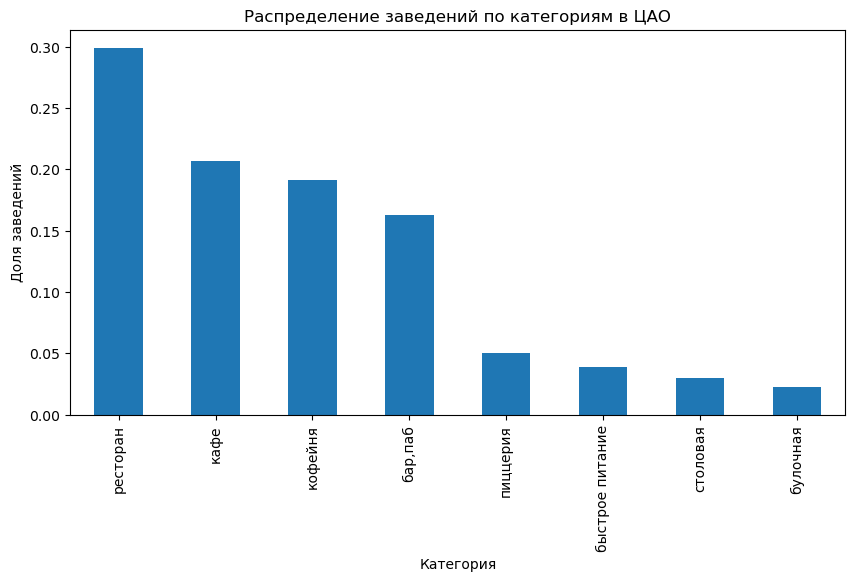

In [31]:
# Визуализируем данные
category_share_cao.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение заведений по категориям в ЦАО')
plt.xlabel('Категория')
plt.ylabel('Доля заведений')
plt.show()

Мы видим, что самым "популярным" районом для открытия заведений является центральный администратиынй округ. Также отметим, что распределение заведений по категориям в ЦАО соответствует общему распределению.

In [32]:
# Найдем распределение заведений по округам в долях
df['district'].value_counts(normalize=True)

district
Центральный административный округ         0.266714
Северный административный округ            0.107066
Южный административный округ               0.106115
Северо-Восточный административный округ    0.105996
Западный административный округ            0.101237
Восточный административный округ           0.094932
Юго-Восточный административный округ       0.084939
Юго-Западный административный округ        0.084345
Северо-Западный административный округ     0.048656
Name: proportion, dtype: float64

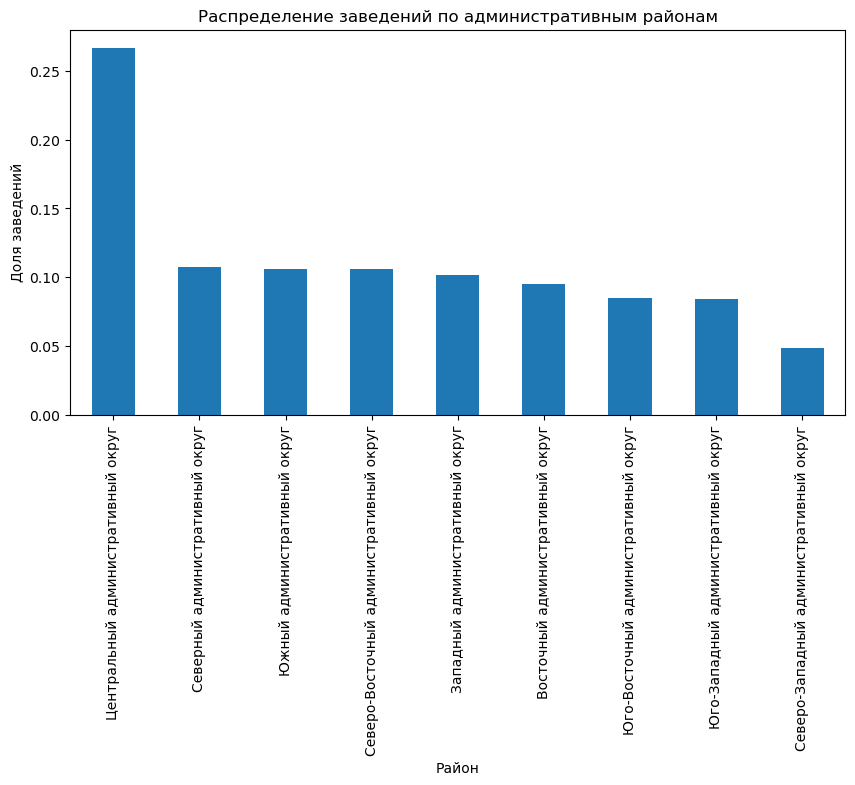

In [33]:
# Визуализируем данные
df['district'].value_counts(normalize=True).plot(kind='bar', figsize=(10, 5))
plt.title('Распределение заведений по административным районам')
plt.xlabel('Район')
plt.ylabel('Доля заведений')
plt.show()

В ЦАО расположены 28% заведений общественного питания Москвы.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

In [34]:
# Подсчитаем количество сетевых и несетевых заведений (chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки): 0 — заведение не является сетевым; 1 — заведение является сетевым.)
df['chain'].value_counts()


chain
0    5201
1    3205
Name: count, dtype: int64

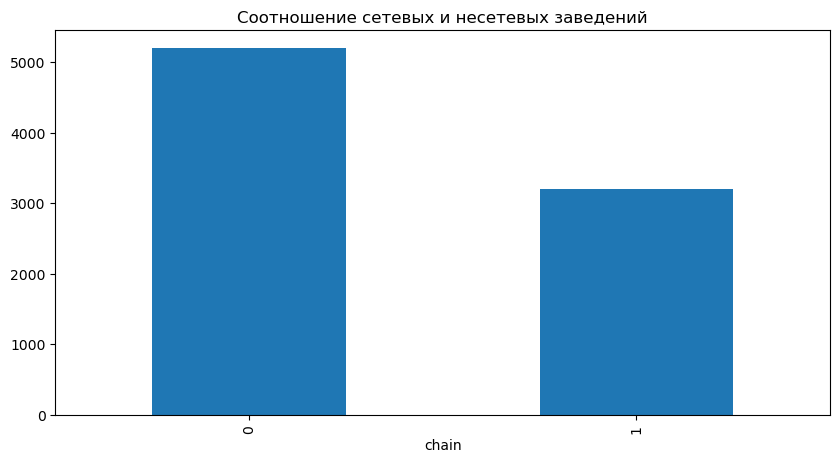

In [35]:
# Визуализируем данные
df['chain'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Соотношение сетевых и несетевых заведений')
plt.xticks(rotation=90)
plt.show()

In [36]:
# Добавим распределение сетевых и несетевых заведений в долях
df['chain'].value_counts(normalize=True)

chain
0    0.618725
1    0.381275
Name: proportion, dtype: float64

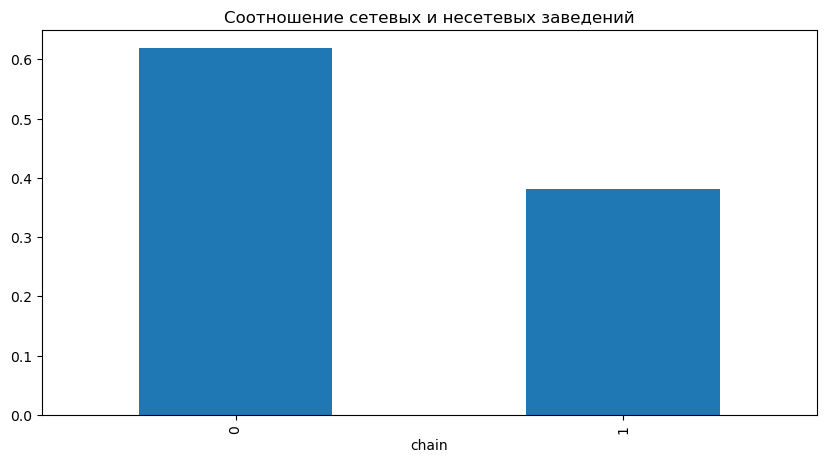

In [37]:
# Визуализируем данные
df['chain'].value_counts(normalize=True).plot(kind='bar', figsize=(10, 5))
plt.title('Соотношение сетевых и несетевых заведений')
plt.xticks(rotation=90)
plt.show()

In [38]:
# Проанализируем распределение сетевых заведений по категориям
category_chain_counts = df[df['chain'] == 1].groupby('category').size()
print(category_chain_counts)

category
бар,паб            169
булочная           157
быстрое питание    232
кафе               779
кофейня            720
пиццерия           330
ресторан           730
столовая            88
dtype: int64


In [39]:
# Сортируем данные в порядке убывания
category_chain_counts_sorted = category_chain_counts.sort_values(ascending=False)


<function matplotlib.pyplot.show(close=None, block=None)>

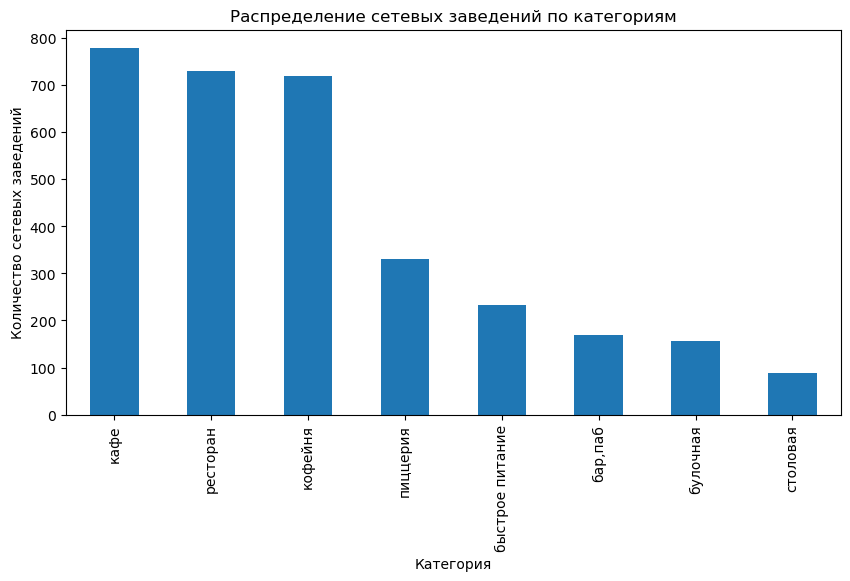

In [40]:
# Визуализируем данные
category_chain_counts_sorted.plot(kind='bar', figsize=(10, 5))
plt.title('Распределение сетевых заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество сетевых заведений')
plt.show


In [41]:
# Проанализируем распределение сетевых заведений по категориям в относительном значении
df[df['chain'] == 1].groupby('category').size().div(df[df['chain'] == 1].shape[0]).sort_values(ascending=False)

category
кафе               0.243058
ресторан           0.227769
кофейня            0.224649
пиццерия           0.102964
быстрое питание    0.072387
бар,паб            0.052730
булочная           0.048986
столовая           0.027457
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

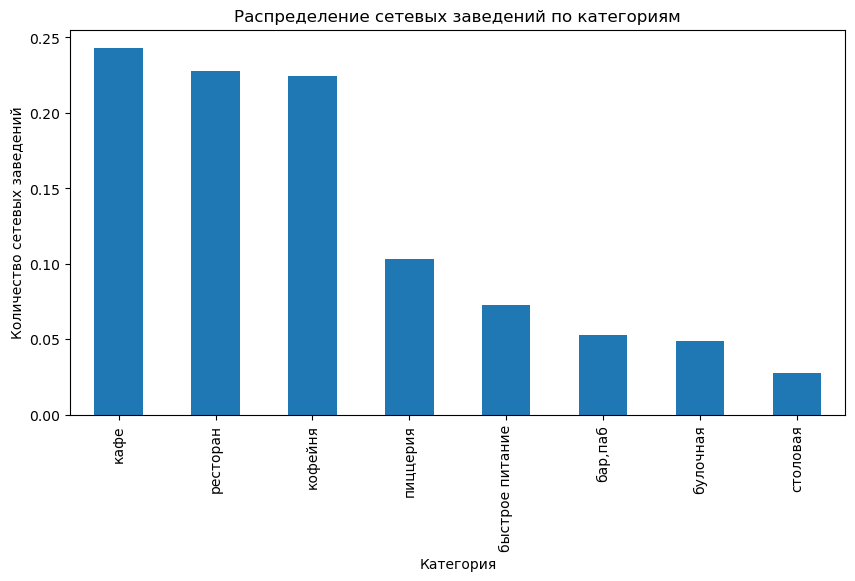

In [42]:
# Визуализируем данные
df[df['chain'] == 1].groupby('category').size().div(df[df['chain'] == 1].shape[0]).sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title('Распределение сетевых заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество сетевых заведений')
plt.show

Мы видим, что несетевых заведений примерно в 1,5 раза больше, чем сетевых.

Сетевыми заведениями чаще всего являются кафе (779 или 24,3%), рестораны (730 или 22,8%) и кофейни (720 или 22,5%). Реже всего среди сетевых заведений встречаются столовые (88 или 2,7%). 

---

### Задача 4

Исследуем количество посадочных мест в заведениях. 

In [43]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

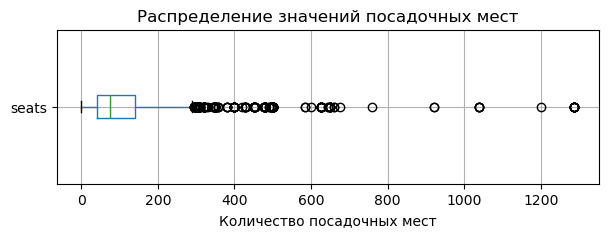

In [44]:
# Визуализируем распределение значений посадочных мест с помощью "ящика с усами"
plt.figure(figsize=(7, 2))
df.boxplot(column='seats', vert=False)
plt.title('Распределение значений посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.show()

Полученное распределение показывает, что данные имеют правостороннее (положительное) смещение (асимметрию): большинство значений сосредоточено в левой части распределения, а меньшая часть — в правой, также справа есть выбросы, которые увеличивают разброс данных в этом направлении.

Среднее количество посадочных мест: 109. 75% заведений имеют до 140 посадочных мест, а 25% — больше. Максимальное количество посадочных мест: 1288 мест. Такое высокое значение указывает на наличие аномальных значений (или очень крупных заведений).

In [45]:
# Сгруппируем данные по категориям заведений и вычислим медианное количество посадочных мест для каждой из них
df.groupby('category')['seats'].median().reset_index()



,category,seats
0,"бар,паб",82.5
1,булочная,50.0
2,быстрое питание,65.0
3,кафе,60.0
4,кофейня,80.0
5,пиццерия,55.0
6,ресторан,86.0
7,столовая,75.5


In [46]:
# Отсортируем полученные значения в порядке убывания
df.groupby('category')['seats'].median().reset_index().sort_values(by='seats', ascending=False)

,category,seats
6,ресторан,86.0
0,"бар,паб",82.5
4,кофейня,80.0
7,столовая,75.5
2,быстрое питание,65.0
3,кафе,60.0
5,пиццерия,55.0
1,булочная,50.0


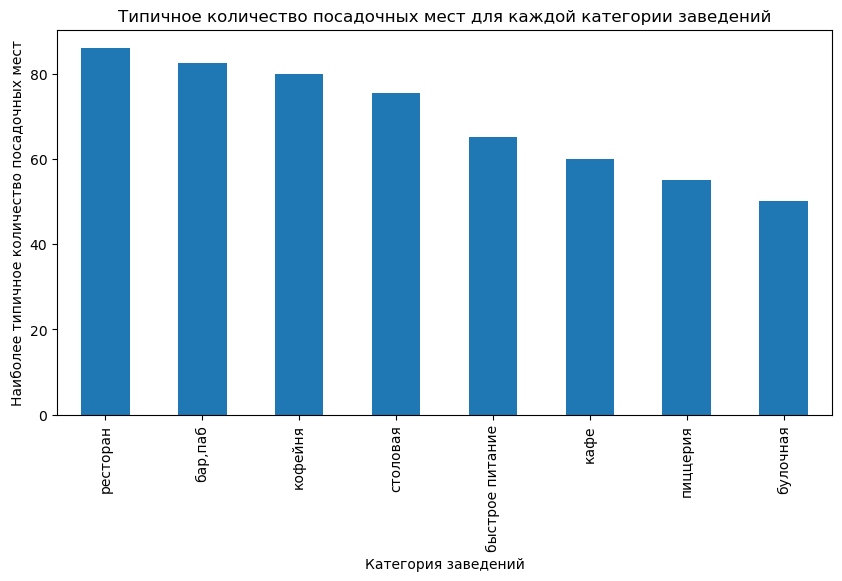

In [47]:
# Визуализируем данные
plt.figure(figsize=(10, 5))
df.groupby('category')['seats'].median().sort_values(ascending=False).plot(kind='bar', x='category', y='seats')
plt.title('Типичное количество посадочных мест для каждой категории заведений')
plt.xlabel('Категория заведений')
plt.ylabel('Наиболее типичное количество посадочных мест')
plt.show()

---

### Задача 5

Исследуем рейтинг заведений. 

In [48]:
# Cгруппируем данные по категориям заведений и вычислим средний рейтинг для каждой категории
df.groupby('category')['rating'].mean().reset_index()

,category,rating
0,"бар,паб",4.387712
1,булочная,4.268359
2,быстрое питание,4.050249
3,кафе,4.123886
4,кофейня,4.277282
5,пиццерия,4.301264
6,ресторан,4.290357
7,столовая,4.211429


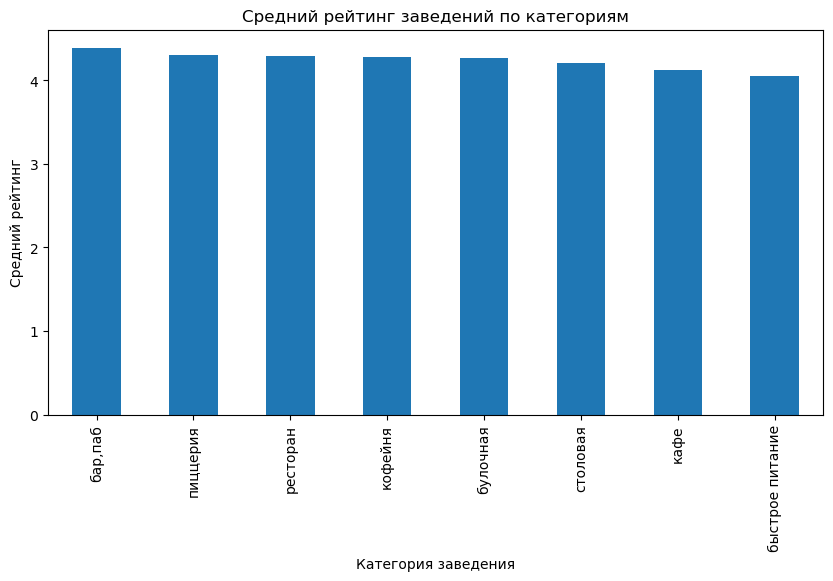

In [49]:
# Визуализируем данные
plt.figure(figsize=(10, 5))
df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(kind='bar', x='category', y='rating')
plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Средний рейтинг')
plt.show()

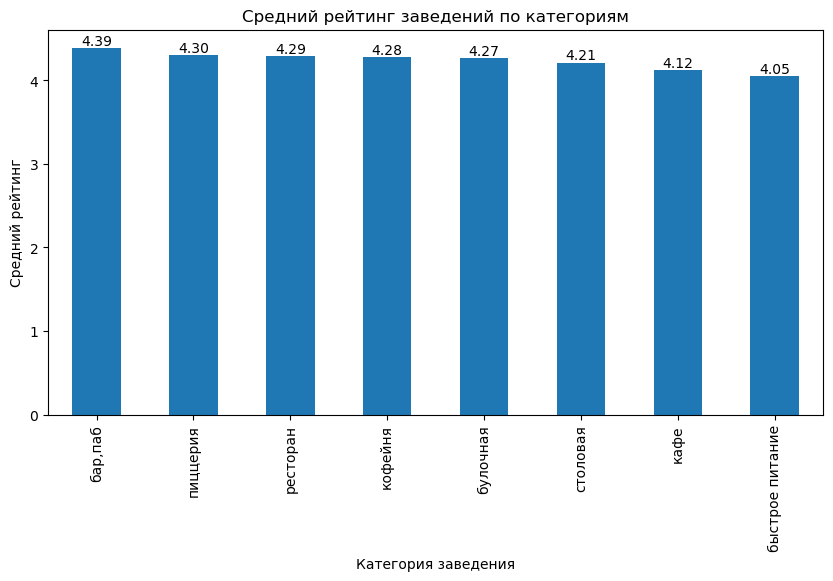

In [50]:
plt.figure(figsize=(10, 5))
ratings = df.groupby('category')['rating'].mean().sort_values(ascending=False)
ratings.plot(kind='bar', x='category', y='rating')

# Добавляем числовые значения над столбцами
for i, v in enumerate(ratings):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.title('Средний рейтинг заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Средний рейтинг')
plt.show()


Мы видим, что усреднённые рейтинги для разных типов общепита практически не отличаются. Они находятся в диапазоне от 4,05 (быстрое питание) до 4,39 (бар,паб).

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. 

In [51]:
# Сгруппируем данные по названию заведения и посчитаем количество заведений для каждой сети
df[df['chain'] == 1].groupby('name').size().reset_index(name='count')


,name,count
0,1-я Креветочная,1
1,10 Идеальных Пицц,3
2,18 Грамм,3
3,4 Сезона,1
4,7 Сэндвичей,4
...,...,...
757,Я люблю суши,4
758,Ян Примус,3
759,Яндекс Лавка,69
760,Яндекс.Лавка,3


In [52]:
# Отсортируем полученные данные по количеству заведений в порядке убывания и выберм топ-15 сетей
top_chains = df[df['chain'] == 1].groupby('name').size().reset_index(name='count').sort_values(by='count', ascending=False).head(15)
print(top_chains)

                                    name  count
746                          Шоколадница    120
344                       Домино'с Пицца     76
340                           Додо Пицца     74
148                     One Price Coffee     71
759                         Яндекс Лавка     69
59                                 Cofix     65
170                                Prime     50
679                           Хинкальная     44
378                             КОФЕПОРТ     42
431  Кулинарная лавка братьев Караваевых     39
643                              Теремок     38
699                              Чайхана     37
40                              CofeFest     32
273                              Буханка     32
491                                Му-Му     27


In [53]:
# Сгруппируем данные по названию и вычислим средние рейтинги
avg_ratings = df[df['chain'] == 1].groupby('name')['rating'].mean().reset_index()
print(avg_ratings)


                  name    rating
0      1-я Креветочная  3.700000
1    10 Идеальных Пицц  4.300000
2             18 Грамм  4.466667
3             4 Сезона  4.700000
4          7 Сэндвичей  3.975000
..                 ...       ...
757       Я люблю суши  4.225000
758          Ян Примус  4.533333
759       Яндекс Лавка  3.872464
760       Яндекс.Лавка  3.466667
761     Японская кухня  4.425000

[762 rows x 2 columns]


In [54]:
# Объединим данные о количестве заведений и средних рейтингах
top_chains_with_ratings = pd.merge(top_chains, avg_ratings, on='name')
print(top_chains_with_ratings)

                                   name  count    rating
0                           Шоколадница    120  4.177500
1                        Домино'с Пицца     76  4.169737
2                            Додо Пицца     74  4.286486
3                      One Price Coffee     71  4.064789
4                          Яндекс Лавка     69  3.872464
5                                 Cofix     65  4.075385
6                                 Prime     50  4.116000
7                            Хинкальная     44  4.322727
8                              КОФЕПОРТ     42  4.147619
9   Кулинарная лавка братьев Караваевых     39  4.394872
10                              Теремок     38  4.123684
11                              Чайхана     37  3.924324
12                             CofeFest     32  3.984375
13                              Буханка     32  4.396875
14                                Му-Му     27  4.229630


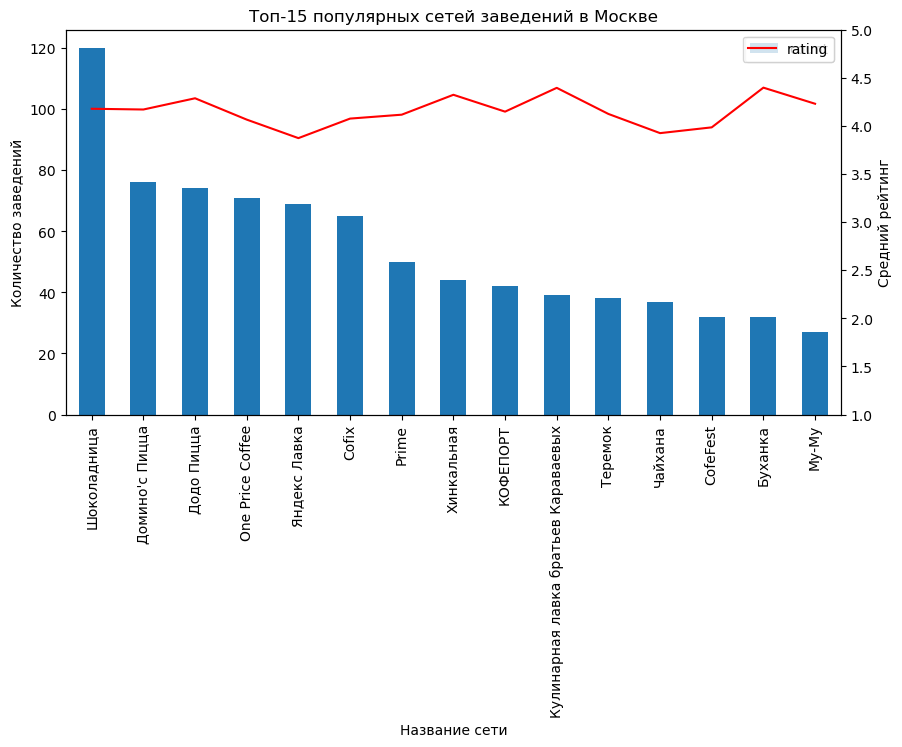

In [55]:
# Визуализируем данные
fig, ax = plt.subplots(figsize=(10, 5))
top_chains_with_ratings.plot(x='name', y='count', kind='bar', ax=ax)
ax2 = ax.twinx()
top_chains_with_ratings.plot(x='name', y='rating', kind='line', ax=ax2, color='r')
ax.set_xlabel('Название сети')
ax.set_ylabel('Количество заведений')
ax2.set_ylim(1, 5)
ax2.set_ylabel('Средний рейтинг')
plt.title('Топ-15 популярных сетей заведений в Москве')
plt.show()

Добавила отбор данных по принадлежности к сетевому заведению, но к полученным данным все равно есть вопросы(((
Хинкальная никуда "не ушла", к тому же появились новые "сомнительные" сетевые заведения..

Самые популярные сети в Москве: Шоколадница (120 заведений), затем идут Домино'с Пицца (76 заведений), Додо пицца (74 заведения) и One Price Coffee (71 заведение).

При этом самый высокий рейтинг (из заведений топ-15) у заведений "Буханка" (4,40) и "Кулинарная лавка братьев Караваевых" (4,39).

In [56]:
# Определим категории для каждой из топовых сетей
categories = df[['name', 'category']].drop_duplicates()
top_chains_info = pd.merge(top_chains_with_ratings, categories, on='name')
print(top_chains_info)

                                   name  count    rating         category
0                           Шоколадница    120  4.177500          кофейня
1                           Шоколадница    120  4.177500             кафе
2                        Домино'с Пицца     76  4.169737         пиццерия
3                            Додо Пицца     74  4.286486         пиццерия
4                      One Price Coffee     71  4.064789          кофейня
5                          Яндекс Лавка     69  3.872464         ресторан
6                                 Cofix     65  4.075385          кофейня
7                                 Prime     50  4.116000         ресторан
8                                 Prime     50  4.116000             кафе
9                            Хинкальная     44  4.322727  быстрое питание
10                           Хинкальная     44  4.322727             кафе
11                           Хинкальная     44  4.322727         ресторан
12                           Хинкальна

Судя по полученным данным, существует сложность в определении категориии заведения общественного питания пользователями ЯндексКарт. Так, например, "Хинкальную" одновременно относят и к кафе, и к ресторану, и к столовой, и к бару,пабу.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других.

In [57]:
# Сгруппируем данные по району и вычислим средний чек для каждого из них
avg_bills_by_district = df.groupby('district')['middle_avg_bill'].mean().reset_index()
print(avg_bills_by_district)

                                  district  middle_avg_bill
0         Восточный административный округ       820.626923
1          Западный административный округ      1053.225490
2          Северный административный округ       927.959627
3  Северо-Восточный административный округ       716.611296
4   Северо-Западный административный округ       822.222930
5       Центральный административный округ      1191.057547
6     Юго-Восточный административный округ       654.097938
7      Юго-Западный административный округ       792.561702
8             Южный административный округ       834.398089


<Figure size 1000x500 with 0 Axes>

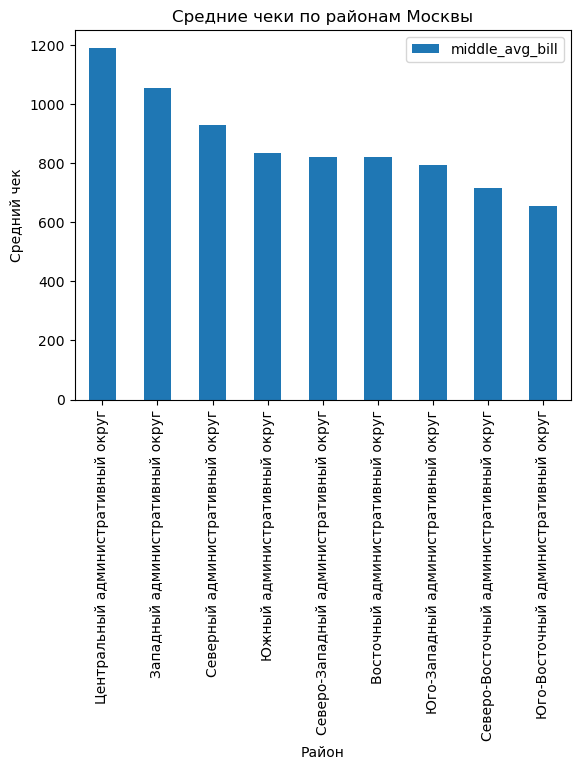

In [58]:
# Визуализируем данные
plt.figure(figsize=(10, 5))
avg_bills_by_district.sort_values(by='middle_avg_bill', ascending=False).plot(kind='bar', x='district', y='middle_avg_bill')
plt.title('Средние чеки по районам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек')
plt.xticks  
plt.show()


---


Самый высокий средний чек наблюдается в Центральном административном округе (ЦАО) — 1191.06 рублей. Это может быть связано с расположением дорогих ресторанов и высоким спросом на услуги в центре города.

Второй по величине средний чек в Западном административном округе — 1053.23 рублей.

Наименьший средний чек отмечается в Юго-Восточном административном округе — 655.00 рублей, что может указывать на более доступные по цене заведения в этом районе.

Средние чеки в других округах варьируются от 716.61 до 927.96 рублей, показывая различия в ценовой политике заведений в зависимости от района.

---

### Промежуточный вывод


Осуществив исследовательский анализ данных, мы выяснили, что:
- больше всего заведений являются кафе (2 003 или 25,4%) и ресторанами (1 969 или 25,0%), а наименьшее число заведений представлено столовыми (306 ил 3,9%) и булочными (249 или 3,2%);

- самым "популярным" районом для открытия заведений является центральный администратиынй округ. В ЦАО расположены 28% заведений общественного питания Москвы. Также отметим, что распределение заведений по категориям в ЦАО соответствует общему распределению;

- несетевых заведений примерно в 1,5 раза больше, чем сетевых (Сетевыми заведениями чаще всего являются кафе (779 или 24,3%), рестораны (730 или 22,8%) и кофейни (720 или 22,5%). Реже всего среди сетевых заведений встречаются столовые (88 или 2,7%));

- среднее количество посадочных мест: 109 мест. 75% заведений имеют до 140 посадочных мест, а 25% — больше. Максимальное количество посадочных мест: 1288 мест. Такое высокое значение указывает на наличие аномальных значений (или очень крупных заведений);

- усреднённые рейтинги для разных типов общепита практически не отличаются. Они находятся в диапазоне от 4,05 (быстрое питание) до 4,39 (бар,паб).

- самые популярные сети в Москве: Шоколадница (120 заведений), затем идут Домино'с Пицца (76 заведений), Додо пицца (74 заведения) и One Price Coffee (71 заведение). При этом самый высокий рейтинг (из заведений топ-15) у заведений "Буханка" (4,40) и "Кулинарная лавка братьев Караваевых" (4,39).;

- самый высокий средний чек наблюдается в Центральном административном округе (ЦАО) — 1 191.06 рублей. Это может быть связано с расположением дорогих заведений и высоким спросом на услуги в центре города. Наименьший средний чек отмечается в Юго-Восточном административном округе — 655.00 рублей, что может указывать на более доступные по цене заведения в этом районе.

## 4. Итоговый вывод и рекомендации


1. Общий обзор проделанной работы:
Изучив датасеты `rest_info` и `rest_price`, мы создали новый - `df`, объединив названные два.

Затем мы изучили пропущенные значения в данных: посчитали их количество в каждом столбце датафрейма, изучили данные с пропущенными значениями и провели обработку пропущенных значений.

Далее мы провели исследовательский анализ данных и постарались ответить на все поставленные вопросы.

2. Основные выводы:

Осуществив исследовательский анализ данных, мы выяснили, что:

- больше всего заведений являются кафе (2 003 или 25,4%) и ресторанами (1 969 или 25,0%), а наименьшее число заведений представлено столовыми (306 ил 3,9%) и булочными (249 или 3,2%);

- самым "популярным" районом для открытия заведений является центральный администратиынй округ. Также отметим, что распределение заведений по категориям в ЦАО соответствует общему распределению;

- несетевых заведений примерно в 1,5 раза больше, чем сетевых (Сетевыми заведениями чаще всего являются кафе (779 или 24,3%), рестораны (730 или 22,8%) и кофейни (720 или 22,5%). Реже всего среди сетевых заведений встречаются столовые (88 или 2,7%). );

- среднее количество посадочных мест: 109 мест. 75% заведений имеют до 140 посадочных мест, а 25% — больше. Максимальное количество посадочных мест: 1288 мест. Такое высокое значение указывает на наличие аномальных значений (или очень крупных заведений);

- самые популярные сети в Москве: Шоколадница (120 заведений), затем идут Домино'с Пицца (76 заведений), Додо пицца (74 заведения) и One Price Coffee (71 заведение). При этом самый высокий рейтинг (из заведений топ-15) у заведений "Буханка" (4,40) и "Кулинарная лавка братьев Караваевых" (4,39).

3. Рекомендации на основе анализа данных: 

Кафе и рестораны, с одной стороны, являются самыми выстребованными заведениями на рынке общественного питания Москвы, а с другой, для новой компании это может представлять трудности, ведь существует большая конкуренция. Также проще всего будет открыть столовую или булочную, однако это, вероятно, не будет приносить много прибыли, т.к. подобные заведения не очень востребованы.

В Центральном административном округе (ЦАО) располагаются наиболее "дорогие" заведения (что, вероятно, продиктовано высоким спросом на услуги в центре города). Более доступные по цене заведения располагаются в Юго-Восточном административном округе (судя по среднему чеку в 655.00 рублей). 

Представленные данные могут быть полезны для принятия решений о выборе места для открытия нового заведения общественного питания в Москве. 